# **Phase 2 — Exploratory Data Analysis**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np

from pathlib import Path
import time

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style = "whitegrid",palette = "colorblind",context = "notebook")
plt.style.use("seaborn-v0_8")
plt.rcParams.update({
    "axes.titlesize" : 12,
    "axes.labelsize" : 8,
    "axes.grid" : True,
    "font.size" : 9,
    "lines.linewidth" : 3
})

In [3]:
np.set_printoptions(precision = 2 , suppress = True)
pd.set_option("display.float_format" , "{:.2f}".format)

In [4]:
ROOT_DIR = Path().cwd().parents[0]
os.chdir(ROOT_DIR)

from src.config import Processed_data, Reports, Figures
os.chdir(ROOT_DIR/Processed_data)

C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\IndiaKart-E-Commerce-Analytics-Project


In [5]:
orders_data = pd.read_csv("orders.csv", parse_dates = ["order_date"])

In [6]:
orders_data.head()

,order_id,customer_id,order_date,order_time,status,city,state,pincode,total_amount,gst_amount,shipping_charge,discount_amount,final_amount,payment_method,shipping_partner,tracking_id,delivered_date,is_cod,channel
0,ORD000001,CUST02946,2025-05-22,17:10:00,Processing,Pune,Maharashtra,300862,100984.19,16364.64,0,20486.45,100984.19,Cash on Delivery,BlueDart,TRK354572763,NaN,1,App
1,ORD000002,CUST04232,2023-10-16,05:32:00,Delivered,Ludhiana,Punjab,387852,254478.01,41599.80,0,19338.79,254478.01,UPI,DTDC,TRK272838570,2023-10-19,0,Website
2,ORD000003,CUST08078,2023-10-08,12:32:00,Cancelled,Meerut,Uttar Pradesh,294014,32557.06,3562.92,0,696.86,32557.06,Debit Card,Amazon Logistics,TRK338505401,NaN,0,App
3,ORD000004,CUST09612,2023-10-02,08:05:00,Delivered,Nashik,Maharashtra,626047,24836.94,3092.88,0,4029.94,24836.94,UPI,DTDC,TRK289792017,2023-09-10,0,Mobile Web
4,ORD000005,CUST03065,2024-06-15,20:19:00,Delivered,Moradabad,Uttar Pradesh,409210,156689.29,25092.36,0,7805.07,156689.29,UPI,Ecom Express,TRK978240041,2024-06-22,0,App


In [7]:
orders_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          50000 non-null  object        
 1   customer_id       50000 non-null  object        
 2   order_date        50000 non-null  datetime64[ns]
 3   order_time        50000 non-null  object        
 4   status            50000 non-null  object        
 5   city              50000 non-null  object        
 6   state             50000 non-null  object        
 7   pincode           50000 non-null  int64         
 8   total_amount      50000 non-null  float64       
 9   gst_amount        50000 non-null  float64       
 10  shipping_charge   50000 non-null  int64         
 11  discount_amount   50000 non-null  float64       
 12  final_amount      50000 non-null  float64       
 13  payment_method    50000 non-null  object        
 14  shipping_partner  5000

In [8]:
orders_data_cp = orders_data.copy()
orders_data_cp = orders_data_cp.set_index("order_date")
monthly_orders = orders_data_cp.resample("ME").count()

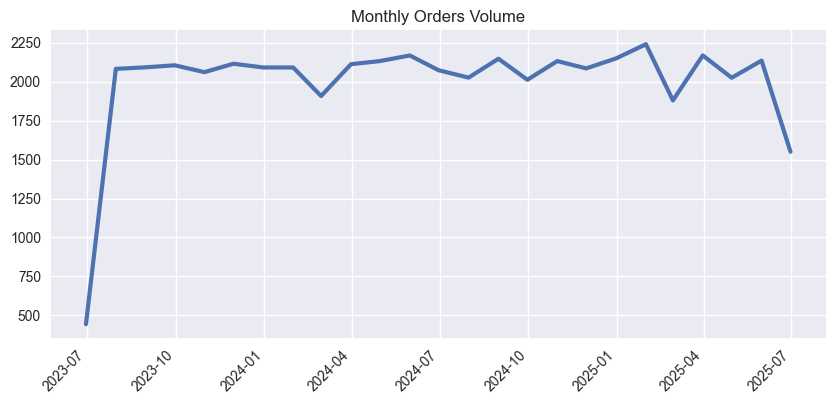

In [9]:
os.chdir(ROOT_DIR/Figures)
plt.figure(figsize = (10,4))
plt.plot(monthly_orders.index,monthly_orders["order_id"])
plt.title("Monthly Orders Volume")
plt.xticks(rotation = 45, ha = "right")
plt.savefig("Monthly Orders Volume.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

- Monthly viewing volume remained relatively low and stable for most of the period, followed by a **sharp increase from 2025 onward**, indicating strong growth in customer engagement.
- The **significant spike in 2026** suggests a major increase in platform activity, which may require IndiaKart to plan inventory, logistics, and operational capacity accordingly.

In [10]:
monthly_revenue = orders_data_cp.resample("ME").sum()

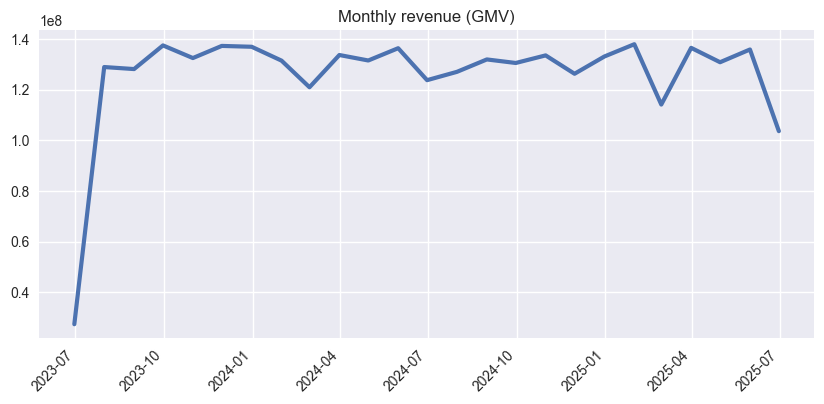

In [11]:
plt.figure(figsize = (10,4))
plt.plot(monthly_revenue.index,monthly_revenue["total_amount"])
plt.title("Monthly revenue (GMV)")
plt.xticks(rotation = 45, ha = "right")
plt.savefig("Monthly revenue (GMV).png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

- Monthly GMV remained relatively **stable around ₹12–14 crore** after the initial period, indicating consistent revenue generation with normal month-to-month fluctuations.
- GMV shows **periodic dips followed by recovery**, suggesting seasonal or operational variations in sales that IndiaKart should consider when planning inventory and promotions.

In [12]:
os.chdir(ROOT_DIR/Processed_data)
order_items_data = pd.read_csv("order_items.csv")
order_items_data.head()

,item_id,order_id,product_id,product_name,category,quantity,unit_price,gst_rate,gst_amount,discount_amount,total_price
0,ITM0000001,ORD000001,PRD0522,HCL Cricket Bat Ultra,Sports & Fitness,1,40989,12,4918.68,7861.45,38046.23
1,ITM0000002,ORD000001,PRD0094,Berger Router Pro,Electronics,1,62532,18,11255.76,12373.11,61414.65
2,ITM0000003,ORD000001,PRD0613,Voltas Educational Toy Standard,Toys & Baby,1,1585,12,190.20,251.89,1523.31
3,ITM0000004,ORD000002,PRD0556,Ambrane Cycle Standard,Sports & Fitness,3,1107,12,398.52,631.44,3088.08
4,ITM0000005,ORD000002,PRD0026,Pebble Tablet Premium,Electronics,2,114448,18,41201.28,18707.35,251389.93


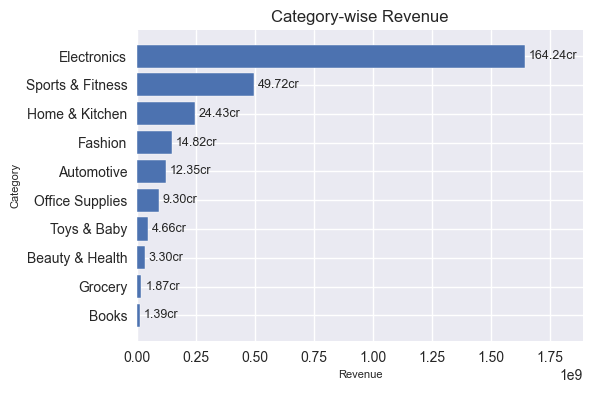

In [13]:
os.chdir(ROOT_DIR/Figures)
total_revenue_by_category = order_items_data.groupby("category")["total_price"].sum().sort_values(ascending = True)

plt.figure(figsize = (6,4))

bars = plt.barh(total_revenue_by_category.index, total_revenue_by_category.values)

for bar in bars:
    width = bar.get_width()
    revenue_cr = width / 10_000_000
    plt.text(
        width + total_revenue_by_category.values.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{revenue_cr:.2f}cr",
        va = "center",
        ha = "left",
        fontsize = 9
    )
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.title("Category-wise Revenue")

plt.xlim(0, total_revenue_by_category.values.max() * 1.15)
plt.tight_layout()
plt.savefig("Category-wise Revenue.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

- **Electronics dominates category revenue** at approximately **₹164.24 Cr**, far exceeding all other categories and making it the primary revenue contributor for IndiaKart.
- **Sports & Fitness and Home & Kitchen** follow with ₹49.72 Cr and ₹24.43 Cr respectively, while categories such as **Books, Grocery, and Beauty & Health** contribute comparatively lower revenue and may require further performance analysis.

In [14]:
orders_data.head()

,order_id,customer_id,order_date,order_time,status,city,state,pincode,total_amount,gst_amount,shipping_charge,discount_amount,final_amount,payment_method,shipping_partner,tracking_id,delivered_date,is_cod,channel
0,ORD000001,CUST02946,2025-05-22,17:10:00,Processing,Pune,Maharashtra,300862,100984.19,16364.64,0,20486.45,100984.19,Cash on Delivery,BlueDart,TRK354572763,NaN,1,App
1,ORD000002,CUST04232,2023-10-16,05:32:00,Delivered,Ludhiana,Punjab,387852,254478.01,41599.80,0,19338.79,254478.01,UPI,DTDC,TRK272838570,2023-10-19,0,Website
2,ORD000003,CUST08078,2023-10-08,12:32:00,Cancelled,Meerut,Uttar Pradesh,294014,32557.06,3562.92,0,696.86,32557.06,Debit Card,Amazon Logistics,TRK338505401,NaN,0,App
3,ORD000004,CUST09612,2023-10-02,08:05:00,Delivered,Nashik,Maharashtra,626047,24836.94,3092.88,0,4029.94,24836.94,UPI,DTDC,TRK289792017,2023-09-10,0,Mobile Web
4,ORD000005,CUST03065,2024-06-15,20:19:00,Delivered,Moradabad,Uttar Pradesh,409210,156689.29,25092.36,0,7805.07,156689.29,UPI,Ecom Express,TRK978240041,2024-06-22,0,App


In [15]:
orders_data["status"].value_counts().values

array([32499,  5996,  5071,  3933,  2501])

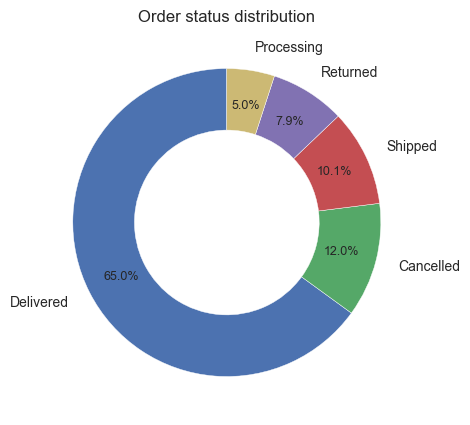

In [16]:
value_counts = orders_data["status"].value_counts()

plt.figure(figsize = (8,5))
plt.pie(
    value_counts.values,
    labels = value_counts.index,
    startangle = 90,
    autopct = "%1.1f%%",
    wedgeprops = {"width" : 0.40},
    pctdistance = 0.77,
    labeldistance = 1.15
)
plt.title("Order status distribution")
plt.savefig("Order status distribution.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

- **65.0% of orders are delivered**, indicating that the majority of IndiaKart orders are successfully completed.
- **12.0% of orders are cancelled and 7.9% are returned**, highlighting areas where IndiaKart can investigate order cancellations and product/service issues to improve fulfillment and customer satisfaction.

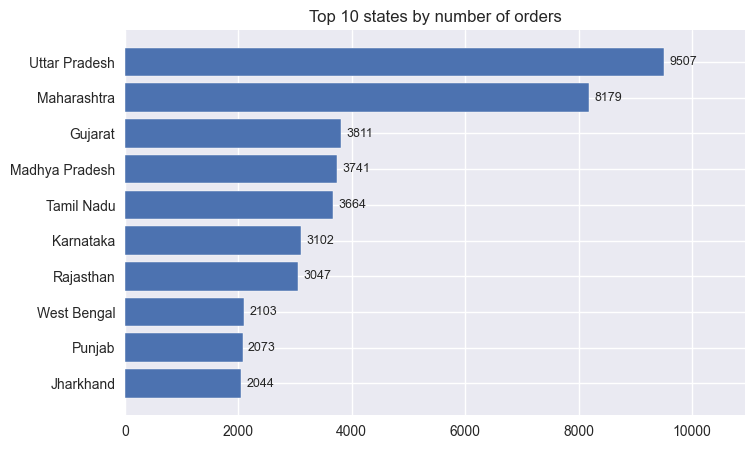

In [17]:
gouped_by_state = orders_data.groupby("state")["order_id"].count().sort_values(ascending = False)
top_10_states = gouped_by_state.head(10).sort_values(ascending = True)
plt.figure(figsize = (8,5))

bars = plt.barh(top_10_states.index, top_10_states.values)

for bar in bars:
    wight = bar.get_width()
    plt.text(
        wight + top_10_states.values.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{wight:.0f}",
        va = "center",
        ha = "left"
    )
plt.title("Top 10 states by number of orders")
plt.xlim(0, top_10_states.values.max() * 1.15)
plt.savefig("Top 10 states by number of orders.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

- **Uttar Pradesh leads with 9,507 orders**, followed by **Maharashtra with 8,179**, making these the two largest state-level markets for IndiaKart.
- **Gujarat, Madhya Pradesh, and Tamil Nadu** form the next group with around **3,600–3,800 orders**, indicating additional high-demand markets that can be targeted for regional growth.

In [18]:
os.chdir(ROOT_DIR/Processed_data)
customers_data = pd.read_csv("customers.csv")
customers_data.head()

,customer_id,first_name,last_name,email,phone,city,state,pincode,gender,age,segment,registration_date,last_login_date,is_verified,is_active,total_orders,total_spent
0,CUST00001,Kunal,Gupta,kunal.gupta223@gmail.com,9117912889,Guwahati,Assam,314040,Male,54,New,2024-07-30,2025-10-04,0,1,7,1028341.51
1,CUST00002,Aryan,Gupta,aryan.gupta336@yahoo.in,9271550550,Navi Mumbai,Maharashtra,799535,Female,26,Budget,2023-07-05,2024-03-05,1,1,1,20337.39
2,CUST00003,Akash,Chatterjee,akash.chatterjee584@hotmail.com,9559676548,Surat,Gujarat,738196,Female,24,Regular,2022-05-14,2023-10-31,1,1,7,265688.26
3,CUST00004,Madhuri,Walia,madhuri.walia878@gmail.com,9673322422,Gwalior,Madhya Pradesh,238106,Female,23,Regular,2025-01-21,2025-05-22,1,0,7,173446.94
4,CUST00005,Vishal,Das,vishal.das342@yahoo.in,9920855521,Dhanbad,Jharkhand,783291,Female,59,Regular,2023-06-06,2024-03-29,1,0,4,239808.60


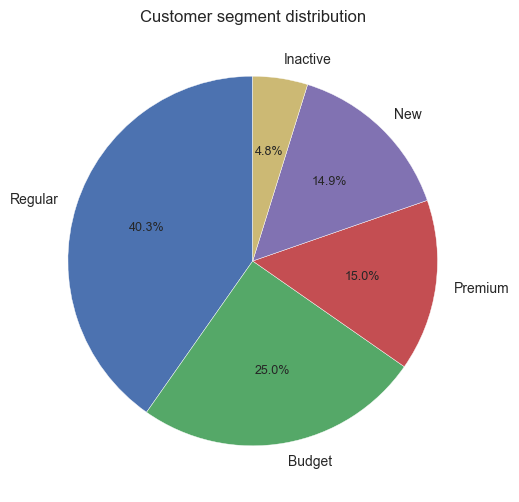

In [19]:
os.chdir(ROOT_DIR/Figures)
segmnet_counts = customers_data["segment"].value_counts()

plt.figure(figsize = (8,6))
plt.pie(
    segmnet_counts.values,
    labels = segmnet_counts.index,
    startangle = 90,
    autopct = "%1.1f%%"
)
plt.title("Customer segment distribution")
plt.savefig("Customer segment distribution.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

- **Regular customers form the largest segment at 40.3%**, followed by **Budget customers at 25.0%**, indicating that repeat and value-focused customers make up a substantial share of IndiaKart's customer base.
- **Premium customers account for 15.0%**, while **New customers represent 14.9%** and **Inactive customers only 4.8%**, highlighting opportunities to convert new customers and increase engagement among inactive users.

In [20]:
os.chdir(ROOT_DIR/Processed_data)
payments_data = pd.read_csv("payments.csv")
payments_data.head()

,payment_id,order_id,customer_id,payment_date,payment_time,payment_method,amount,status,transaction_id,bank_name,gateway,refund_amount,refund_date
0,PAY000001,ORD000001,CUST02946,2025-05-22,17:10:00,Cash on Delivery,100984.19,Success,TXN5110698474,SBI,Google Pay,0,NaN
1,PAY000002,ORD000002,CUST04232,2023-10-16,05:32:00,UPI,254478.01,Success,TXN4067460377,IndusInd,Google Pay,0,NaN
2,PAY000003,ORD000003,CUST08078,2023-08-10,12:32:00,Debit Card,32557.06,Success,TXN7056710694,Axis Bank,PhonePe,0,NaN
3,PAY000004,ORD000004,CUST09612,2023-02-10,08:05:00,UPI,24836.94,Success,TXN7460208257,Axis Bank,PhonePe,0,NaN
4,PAY000005,ORD000005,CUST03065,2024-06-15,20:19:00,UPI,156689.29,Success,TXN5835043807,PNB,Razorpay,0,NaN


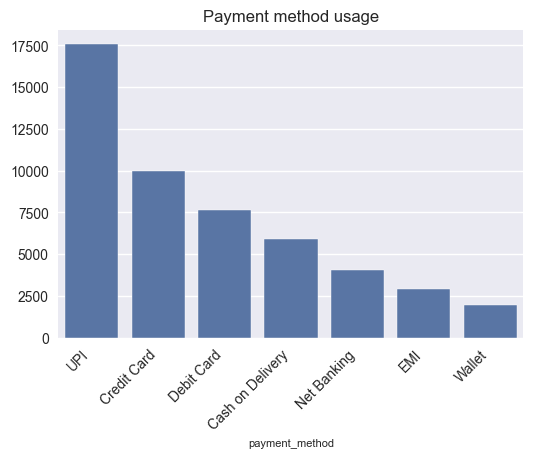

In [21]:
os.chdir(ROOT_DIR/Figures)
payment_method_counts = payments_data["payment_method"].value_counts()

plt.figure(figsize = (6,4))
sns.barplot(x = payment_method_counts.index, y = payment_method_counts.values)
plt.title("Payment method usage")
plt.xticks(rotation = 45, ha = "right")
plt.savefig("Payment method usage.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

- **UPI is the most widely used payment method**, followed by Credit Card and Debit Card, showing a strong preference for digital payments among IndiaKart customers.
- **Wallet and EMI have the lowest usage**, indicating relatively lower adoption compared with UPI and card-based payment methods.

In [22]:
customers_data.describe()

,phone,pincode,age,is_verified,is_active,total_orders,total_spent
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,9554707115.67,451127.44,41.68,0.84,0.88,5.00,314738.55
std,261696209.39,201801.01,13.83,0.36,0.33,3.07,290326.63
min,9100092658.00,100006.00,18.00,0.00,0.00,0.00,0.00
25%,9327842045.75,277245.25,30.00,1.00,1.00,3.00,88423.37
50%,9558695618.50,452011.00,42.00,1.00,1.00,5.00,235661.07
75%,9781826669.50,627402.50,54.00,1.00,1.00,7.00,466058.43
max,9999982555.00,799595.00,65.00,1.00,1.00,19.00,1999913.04


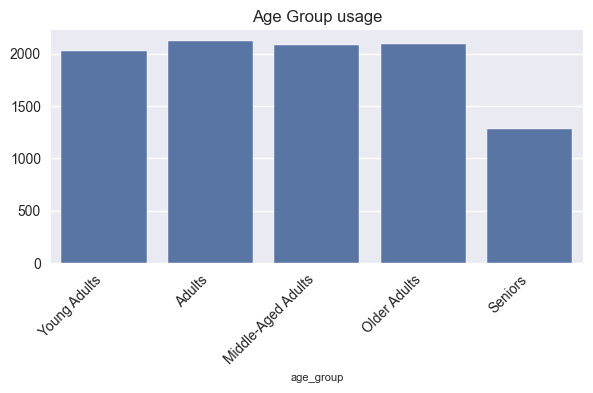

In [23]:
customers_data_cp = customers_data.copy()
bins = [19, 29, 39, 49, 59, 69]
labels = ["Young Adults","Adults","Middle-Aged Adults","Older Adults","Seniors"]
customers_data_cp["age_group"] = pd.cut(customers_data_cp["age"],bins=bins,labels=labels)

age_group_counts = (customers_data_cp["age_group"].value_counts().reindex(labels))

plt.figure(figsize = (6,4))
sns.barplot(x = age_group_counts.index, y = age_group_counts.values)
plt.title("Age Group usage")
plt.xticks(rotation = 45, ha = "right")
plt.savefig("Age Group usage.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.tight_layout()
plt.show()

- **Adults, Middle-Age Adults, and Older Adults** show the highest and relatively similar usage, each with around **2,100 customers**, indicating broad adoption across these age groups.
- **Seniors have the lowest usage at around 1,300 customers**, while Young Adults are also slightly lower than the three leading groups, suggesting scope for stronger engagement among these segments.

In [24]:
os.chdir(ROOT_DIR/Processed_data)
returns_data = pd.read_csv("returns.csv")
returns_data.head(3)

,return_id,order_id,customer_id,return_date,reason,return_amount,refund_status,refund_date,return_condition,remarks
0,RET00001,ORD000015,CUST05470,2024-12-23,Size Issue,24167.33,Pending,2024-12-30,Damaged,Customer initiated return within 7 day window
1,RET00002,ORD000017,CUST07581,2023-01-11,Defective Product,11698.27,Refunded,2023-06-11,Damaged,Customer initiated return within 7 day window
2,RET00003,ORD000038,CUST05691,2025-01-05,Wrong Product Delivered,11147.74,Refunded,2025-06-05,Damaged,Customer initiated return within 7 day window


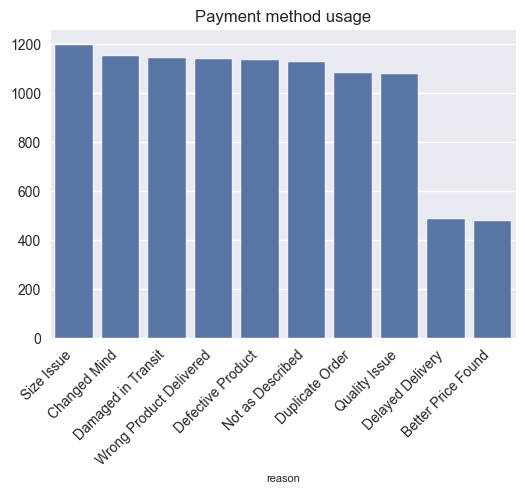

In [25]:
os.chdir(ROOT_DIR/Figures)
return_reason_counts = returns_data["reason"].value_counts()

plt.figure(figsize = (6,4))
sns.barplot(x = return_reason_counts.index, y = return_reason_counts.values)
plt.title("Payment method usage")
plt.xticks(rotation = 45, ha = "right")
plt.savefig("Payment method usage.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

- **Size Issue, Changed Mind, and Damaged in Transit** are the most common return reasons, each accounting for **around 1,150–1,200 cases**, indicating key areas for improving product fit and delivery quality.
- **Delayed Delivery and Better Price Found** have comparatively fewer cases, at **around 500 each**, suggesting these are less frequent return drivers than product-related issues.

In [26]:
orders_data.head()

,order_id,customer_id,order_date,order_time,status,city,state,pincode,total_amount,gst_amount,shipping_charge,discount_amount,final_amount,payment_method,shipping_partner,tracking_id,delivered_date,is_cod,channel
0,ORD000001,CUST02946,2025-05-22,17:10:00,Processing,Pune,Maharashtra,300862,100984.19,16364.64,0,20486.45,100984.19,Cash on Delivery,BlueDart,TRK354572763,NaN,1,App
1,ORD000002,CUST04232,2023-10-16,05:32:00,Delivered,Ludhiana,Punjab,387852,254478.01,41599.80,0,19338.79,254478.01,UPI,DTDC,TRK272838570,2023-10-19,0,Website
2,ORD000003,CUST08078,2023-10-08,12:32:00,Cancelled,Meerut,Uttar Pradesh,294014,32557.06,3562.92,0,696.86,32557.06,Debit Card,Amazon Logistics,TRK338505401,NaN,0,App
3,ORD000004,CUST09612,2023-10-02,08:05:00,Delivered,Nashik,Maharashtra,626047,24836.94,3092.88,0,4029.94,24836.94,UPI,DTDC,TRK289792017,2023-09-10,0,Mobile Web
4,ORD000005,CUST03065,2024-06-15,20:19:00,Delivered,Moradabad,Uttar Pradesh,409210,156689.29,25092.36,0,7805.07,156689.29,UPI,Ecom Express,TRK978240041,2024-06-22,0,App


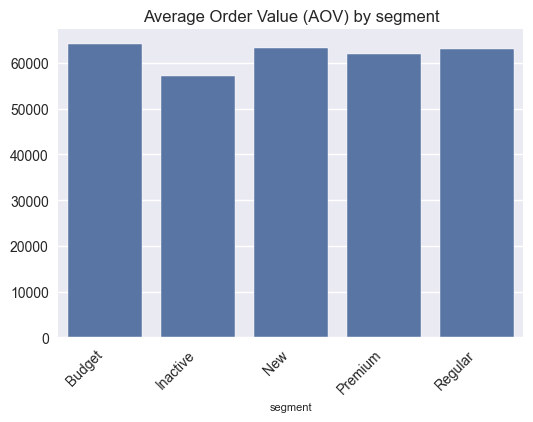

In [27]:
customers_orders_data = customers_data.merge(orders_data, on = "customer_id", how = "left")
aov_by_segment = customers_orders_data.groupby("segment")["total_amount"].mean()

plt.figure(figsize = (6,4))
sns.barplot(x = aov_by_segment.index, y = aov_by_segment.values)
plt.title("Average Order Value (AOV) by segment")
plt.xticks(rotation = 45, ha = "right")
plt.savefig("Average Order Value (AOV) by segment.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

- **Budget, New, and Regular customers have the highest AOV**, at approximately **₹63K–₹64K**, indicating relatively higher spending per order among these segments.
- **Inactive customers have the lowest AOV at around ₹57K**, while Premium customers are close to the overall higher range, suggesting an opportunity to understand spending differences across customer segments.